# Coding Session 07 · Lab W7


## Assignment, contact, and the effect we can defend

We will compare a selected-contact gap with assignment-based effects, keep denominators visible, read uncertainty, and use an AI coding agent to refactor a function we already understand. The real New Haven canvassing example differs from the lab's digital-ad case; the code transfers, the numerical answers do not.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def load_data(filename):
    """Prefer a checkout; use the published repository in Colab."""
    relative = Path("wk07_itt_vs_late") / "data" / filename
    candidates = [Path("data") / filename, relative]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path)
    return pd.read_csv("https://raw.githubusercontent.com/albertostefanelli/DSPC_coding_sessions/master/" + relative.as_posix())

## 1. Read the experiment before writing the comparison

The corrected Gerber–Green New Haven archive records individuals in households. We retain only the columns needed here; no rows were removed from the packaged source extract.

| Field | Meaning |
| :--- | :--- |
| `id1` | Household identifier: rows from one household share assignment. |
| `persngrp` | Random assignment to a personal canvassing visit (1) or not (0). |
| `cntany` | Someone in the household was contacted; it is **not verified contact with each individual**. |
| `vote98` | Individual 1998 turnout, with `99` meaning missing. |
| `mailings`, `phongotv`, `placebo` | Other intervention assignments used to define a simpler comparison. |

Source: Gerber and Green (2005), corrected New Haven replication, [Yale source download](https://isps-yard-aws-s3-bucket.s3.us-east-2.amazonaws.com/published/8bcbc104-5a49-4e86-9134-2a0231b8cf9b/Gerber_Green_APSR_2005_NHrep_individual.csv). See the repository's [data provenance](https://github.com/albertostefanelli/DSPC_coding_sessions/blob/master/wk07_itt_vs_late/data/README.md) for coding and provenance.

This is a transparent teaching reanalysis, **not a reproduction of a published coefficient**. We restrict other intervention assignments to zero so we can interpret a visit-versus-control comparison. We do not select on actual contact. This estimates the effect in that restricted assignment population, assuming the factorial randomization supports this restriction.

In [2]:
raw = load_data("gerber_green_new_haven.csv")
sample = raw.loc[
    (raw["mailings"] == 0)
    & (raw["phongotv"] == 0)
    & (raw["placebo"] == 0)
].copy()
sample["vote98"] = sample["vote98"].replace(99, np.nan)
assert sample.groupby("id1")[["persngrp", "cntany"]].nunique().le(1).all().all()
assert sample[["persngrp", "cntany"]].isin([0, 1]).all().all()
missingness = sample.groupby("persngrp").agg(
    assigned_people=("vote98", "size"),
    observed_outcomes=("vote98", "count"),
    contacted_household_share=("cntany", "mean"),
)
missingness["missing_share"] = 1 - (
    missingness["observed_outcomes"] / missingness["assigned_people"]
)
display(missingness.round(4))
print("Households:", sample["id1"].nunique())

,assigned_people,observed_outcomes,contacted_household_share,missing_share
persngrp,,,,
0,11207,10733,0.0000,0.0423
1,2769,2650,0.3218,0.0430


Households: 10533


**Read the missingness table.** Randomization does not automatically make a complete-case comparison unbiased. Dropping missing turnout requires an additional assumption: within each assignment group, observed rows represent the joint distribution of turnout and household contact needed for both contrasts. This is stronger than equal missingness rates. Similar missing rates alone cannot establish that. We report an assumption-free missing-outcome bound below.

Keep a common complete-case sample for the outcome and contact contrasts so the ratio uses the same population. Report how many observations it keeps.

In [3]:
analysis = sample.dropna(subset=["vote98", "cntany", "persngrp", "id1"]).copy()
print("Complete-case individuals:", len(analysis))
by_assignment = analysis.groupby("persngrp").agg(
    n=("vote98", "size"), turnout=("vote98", "mean"), contact=("cntany", "mean")
)
display(by_assignment)

Complete-case individuals: 13383


,n,turnout,contact
persngrp,,,
0,10733,0.441629,0.000000
1,2650,0.481132,0.327925


## 2. A filter changes the estimand

A naive comparison selects contacted households from the visit arm and compares their members with controls. Reachability may predict turnout even without a visit. The ITT instead compares **all available outcomes by assignment**, including people in households not reached.

Write down the numerator and denominator of each mean before running this cell.

In [4]:
selected = analysis.loc[
    (analysis["persngrp"] == 1) & (analysis["cntany"] == 1), "vote98"
]
naive_gap = selected.mean() - by_assignment.loc[0, "turnout"]
itt = by_assignment.loc[1, "turnout"] - by_assignment.loc[0, "turnout"]
first_stage = by_assignment.loc[1, "contact"] - by_assignment.loc[0, "contact"]
late = itt / first_stage
pd.Series({"Selected-contact gap (pp)": 100 * naive_gap,
           "ITT (pp)": 100 * itt,
           "Contact first stage (pp)": 100 * first_stage,
           "Wald ratio / LATE (pp)": 100 * late})

Selected-contact gap (pp)    13.489612
ITT (pp)                      3.950345
Contact first stage (pp)     32.792453
Wald ratio / LATE (pp)       12.046508
dtype: float64

,observed_people,turnout
contact_group,,
"Assigned, household contacted",869,0.576525
"Assigned, not contacted",1781,0.434587
Control,10733,0.441629


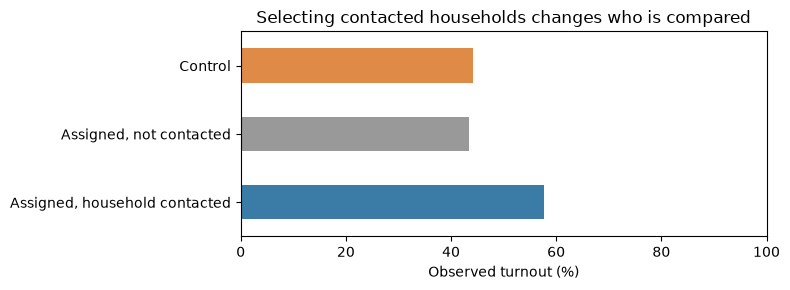

In [5]:
# A supplied visual comparison, matching the lab's interpretation task.
plot_sample = analysis.assign(contact_group=np.select(
    [analysis["persngrp"].eq(0), analysis["cntany"].eq(1)],
    ["Control", "Assigned, household contacted"],
    default="Assigned, not contacted",
))
contact_table = plot_sample.groupby("contact_group")["vote98"].agg(["size", "mean"])
display(contact_table.rename(columns={"size": "observed_people", "mean": "turnout"}))
contact_means = contact_table["mean"]
ax = (100 * contact_means).plot.barh(figsize=(8, 3), color=["#3a7ca5", "#999999", "#df8a47"])
ax.set(xlabel="Observed turnout (%)", ylabel="", title="Selecting contacted households changes who is compared", xlim=(0, 100))
plt.tight_layout()
plt.show()

The **first stage** is contact in the assigned group minus contact in controls. Here control contact is zero; in another experiment it may not be. Dividing only by treated contact is then wrong.

The Wald ratio has a LATE interpretation only with random assignment, a nonzero first stage, exclusion (assignment affects turnout only through household contact), monotonicity (assignment does not prevent contact), and no relevant spillovers across households. It describes individuals in households whose contact status changes because of assignment, under this household exposure definition and the missingness assumption. It is not an effect for every viewer, voter, or campaign.

### The assignment contrast as a regression

An intercept and a binary assignment indicator reproduce the difference in means. Read the coefficient, standard error, p-value, and confidence interval in the supplied output, as in the lab. We cluster at household because this file includes multiple people per assignment unit.

In [6]:
import statsmodels.formula.api as smf
itt_model = smf.ols("vote98 ~ persngrp", data=analysis).fit(
    cov_type="cluster", cov_kwds={"groups": analysis["id1"]}
)
lo, hi = itt_model.conf_int().loc["persngrp"]
print("ITT: " + format(100 * itt_model.params['persngrp'], ".2f") + " pp")
print("Standard error: " + format(100 * itt_model.bse['persngrp'], ".2f") + " pp")
print("P-value: " + format(itt_model.pvalues['persngrp'], ".4f"))
print("Approximate 95% interval: [" + format(100 * lo, ".2f") + ", " + format(100 * hi, ".2f") + "] pp")
np.testing.assert_allclose(itt_model.params["persngrp"], itt)

ITT: 3.95 pp
Standard error: 1.24 pp
P-value: 0.0015
Approximate 95% interval: [1.52, 6.38] pp


## 3. Read uncertainty at the assignment unit

Members of the same household are not independent assignments. The supplied helper below sums contributions **within household** before computing uncertainty. For the ratio, it uses a delta-method approximation that accounts for uncertainty in both ITT and first stage. You are expected to run and interpret this scaffold, not derive it.

A weak or near-zero first stage makes the ratio unstable; this normal approximation is not reliable for a weak instrument.

In [7]:
def assignment_summary(data):
    """Complete-case, individual-weighted means; household-clustered uncertainty."""
    required = ["id1", "persngrp", "cntany", "vote98"]
    clean = data[required].dropna().copy()
    if set(clean["persngrp"]) != {0, 1}:
        raise ValueError("Both assignment groups are required.")
    if not clean[["cntany", "vote98"]].isin([0, 1]).all().all():
        raise ValueError("Recode missing outcomes before calling this function.")
    if not clean.groupby("id1")["persngrp"].nunique().eq(1).all():
        raise ValueError("Households must have a single assignment.")
    means = clean.groupby("persngrp")[["vote98", "cntany"]].mean()
    counts = clean["persngrp"].value_counts()
    differences = means.loc[1] - means.loc[0]
    # Each row contributes to its group mean; preserve the covariance of both contrasts.
    sign = clean["persngrp"].map({0: -1, 1: 1})
    contributions = pd.DataFrame(index=clean.index)
    for column in ["vote98", "cntany"]:
        centered = clean[column] - clean["persngrp"].map(means[column])
        contributions[column] = sign * centered / clean["persngrp"].map(counts)
    cluster_sums = contributions.groupby(clean["id1"]).sum().to_numpy()
    n_clusters = len(cluster_sums)
    if n_clusters < 3:
        raise ValueError("At least three households are needed for uncertainty.")
    covariance = cluster_sums.T @ cluster_sums * n_clusters / (n_clusters - 1)
    effect, stage = differences["vote98"], differences["cntany"]
    if abs(stage) < 1e-8:
        raise ValueError("First stage is zero; the ratio is undefined.")
    gradient = np.array([1 / stage, -effect / stage**2])
    estimates = np.array([effect, stage, effect / stage])
    standard_errors = np.array([
        np.sqrt(covariance[0, 0]), np.sqrt(covariance[1, 1]),
        np.sqrt(gradient @ covariance @ gradient),
    ])
    return pd.DataFrame({
        "estimate": estimates, "se": standard_errors,
        "low": estimates - 1.96 * standard_errors,
        "high": estimates + 1.96 * standard_errors,
        "n_people": len(clean), "n_households": n_clusters,
    }, index=["ITT", "first_stage", "LATE"])

summary = assignment_summary(analysis)
display(summary.round(4))

,estimate,se,low,high,n_people,n_households
ITT,0.0395,0.0124,0.0152,0.0638,13383,10067
first_stage,0.3279,0.0112,0.3059,0.3500,13383,10067
LATE,0.1205,0.0376,0.0468,0.1942,13383,10067


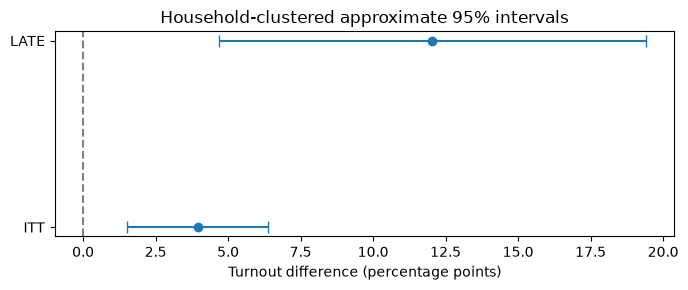

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
plotted = summary.loc[["ITT", "LATE"]]
ax.errorbar(100 * plotted["estimate"], plotted.index,
            xerr=100 * 1.96 * plotted["se"], fmt="o", capsize=4)
ax.axvline(0, color="gray", linestyle="--")
ax.set(xlabel="Turnout difference (percentage points)",
       title="Household-clustered approximate 95% intervals")
plt.tight_layout()
plt.show()

**Interpret:** Which interval is wider, and why? Would excluding uncontacted people improve precision while preserving the ITT estimand? Explain the problem with that proposal.



### Missing-outcome sensitivity

For each assignment group, set every missing turnout to 0 for its lowest possible mean and to 1 for its highest. The lowest effect uses the lowest treated mean minus the highest control mean. These are **identification bounds**, not confidence intervals; they do not include sampling uncertainty.

In [9]:
bounds = sample.groupby("persngrp")["vote98"].agg(
    n="size", observed="count", votes="sum"
)
bounds["lowest_mean"] = bounds["votes"] / bounds["n"]
bounds["highest_mean"] = (bounds["votes"] + bounds["n"] - bounds["observed"]) / bounds["n"]
print("Full restricted-sample turnout-difference bounds (pp):",
      (100 * (bounds.loc[1, "lowest_mean"] - bounds.loc[0, "highest_mean"]),
       100 * (bounds.loc[1, "highest_mean"] - bounds.loc[0, "lowest_mean"])))

Full restricted-sample turnout-difference bounds (pp): (np.float64(-0.47898982807622614), np.float64(8.048089945847515))


## 4. Coding with an AI agent: refactor, then verify

First explain `assignment_summary` in your own words: inputs, exclusions, grouping, outputs, and checks. Open your available coding agent in a working copy of this exercise; confirm its working directory, Python runtime, and data paths. An agent running on your computer does not automatically share Colab's runtime.

| A bounded prompt |
| :--- |
| Refactor `assignment_summary` into clearer small helpers. Preserve the same complete-case rows, household groups, individual-weighted means, ITT, first stage, ratio, standard errors, and output columns. Do not change the estimator, missing-data rule, covariance formula, or install packages. Explain each change. Keep the original function and name the proposed function `assignment_summary_refactored`. Show how you would check agreement on the supplied data and a hand-worked example. |

Paste only the proposed function into a new cell. Read its changes before running it. The agent does not decide whether exclusion, monotonicity, or the missingness assumption is credible.

In [10]:
# A hand-worked example: control means = 1/2 and 0;
# treatment means = 3/4 and 1/2. ITT = 1/4, first stage = 1/2, ratio = 1/2.
tiny = pd.DataFrame({
    "id1": range(8), "persngrp": [0, 0, 0, 0, 1, 1, 1, 1],
    "cntany": [0, 0, 0, 0, 1, 1, 0, 0],
    "vote98": [0, 1, 0, 1, 1, 1, 1, 0],
})
np.testing.assert_allclose(assignment_summary(tiny)["estimate"], [0.25, 0.5, 0.5])
# After reviewing and running the proposed function, uncomment both checks:
# pd.testing.assert_frame_equal(assignment_summary_refactored(analysis), summary)
# pd.testing.assert_frame_equal(assignment_summary_refactored(tiny), assignment_summary(tiny))

## Further practice

1. Write a grouped table showing turnout and group size for assigned contacted, assigned uncontacted, and control individuals. Explain which rows would disappear if you conditioned on contact.
2. In a clearly labeled hypothetical program, assignment costs 4 currency units per person. Write the cost-per-additional-vote calculation using ITT. Explain why dividing this assignment cost by LATE would mismatch denominators and why an interval covering zero complicates the price.
3. Check that the AI refactor rejects an unreplaced `99` and a zero first stage. Reject changes that silently alter rows or cluster definitions.
4. Connect the missingness bounds with what the complete-case interval can establish. Keep the lab's client recommendation as your own assignment work.



## Optional: retain the DIME function/loop practice

DIME is observational. Changing a threshold changes the description of candidate groups; it does not randomize ideology. The familiar finance data remain available for practicing loops and categories.

In [11]:
dime = load_data("dime_candidates_2020_2024_clean.csv")
dime_clean = dime[["recipient.cfscore.dyn", "total.receipts"]].dropna().copy()
rows = []
for threshold in [0.25, 0.5, 0.75]:
    moderate = dime_clean["recipient.cfscore.dyn"].abs() <= threshold
    rows.append({"threshold": threshold,
                 "moderate_n": int(moderate.sum()),
                 "receipt_gap": (dime_clean.loc[moderate, "total.receipts"].mean()
                                  - dime_clean.loc[~moderate, "total.receipts"].mean())})
pd.DataFrame(rows)

,threshold,moderate_n,receipt_gap
0,0.25,75,-303288.842944
1,0.50,201,-466479.412329
2,0.75,420,-863317.113869


### Categorizing candidates with a function

We can translate a continuous ideology score into categories for comparison. These inherited cutoffs and labels are **illustrative coding rules**, not validated political identities or evidence about why donors give. Choosing cutoffs after examining receipts can make a description look more persuasive than it is.

In [12]:
def categorize_ideology(score):
    if pd.isna(score):
        return pd.NA
    if -0.5 <= score <= 0.5:
        return "True centrist"
    elif (-0.9 <= score < -0.5) or (0.5 < score <= 0.9):
        return "Soft partisan"
    elif (-1.7 <= score < -0.9) or (0.9 < score <= 1.7):
        return "Mainstream"
    else:
        return "Extreme"

To assign each candidate to one of these categories, we use the `.apply()` method in pandas.

`.apply()` runs a function on every element of a Series — in this case, the ideology column — and stores the returned value in a new column.

So for every candidate:

- Their ideology value (e.g., +1.2) is passed to `categorize_ideology()`.
- The function checks which range it falls into.
- The corresponding label (e.g., "Mainstream") is returned and stored in a new column.

Handle missing scores before assigning a category; otherwise the final `else` could incorrectly label them extreme.

In [13]:
dime["ideology_c"] = dime["recipient.cfscore.dyn"].apply(categorize_ideology)
dime["total.receipts_m"] = dime["total.receipts"] / 1_000_000
display(dime["ideology_c"].value_counts(dropna=False))
display(dime.groupby("ideology_c")["total.receipts_m"].agg(["size", "mean", "median"]))

ideology_c
Mainstream       1890
Soft partisan     477
True centrist     201
NaN                98
Extreme            93
Name: count, dtype: int64

,size,mean,median
ideology_c,,,
Extreme,93,4.208477,0.022488
Mainstream,1890,1.920431,0.084315
Soft partisan,477,3.981888,0.578602
True centrist,201,1.940173,0.216124


### From lists to long data and a faceted plot

The original multi-result workflow stored an array in each table row and used `.explode()` to turn those arrays into one value per row. Here we practice that same data shape with observed fundraising values. A `FacetGrid` makes one panel per category. Shared axes let us compare distributions directly.

The display uses nonnegative observed receipts and `log1p` (log of 1 plus receipts), because the raw distribution has a long tail. This is a display choice, not an adjustment for confounding. No permutation significance claim is attached to these nonrandomized categories.

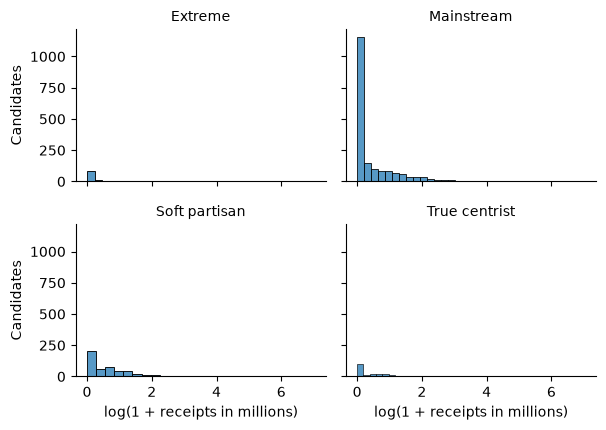

In [14]:
import seaborn as sns
plot_rows = dime.dropna(subset=["ideology_c", "total.receipts_m"])
plot_rows = plot_rows.loc[plot_rows["total.receipts_m"] >= 0].copy()
# Collect a list in each category row, then return to a long table.
category_lists = plot_rows.groupby("ideology_c")["total.receipts_m"].agg(list).reset_index()
long_receipts = category_lists.explode("total.receipts_m", ignore_index=True)
long_receipts["total.receipts_m"] = long_receipts["total.receipts_m"].astype(float)
long_receipts["log1p_receipts_m"] = np.log1p(long_receipts["total.receipts_m"])
grid = sns.FacetGrid(long_receipts, col="ideology_c", col_wrap=2,
                     sharex=True, sharey=True, height=2.2, aspect=1.4)
grid.map_dataframe(sns.histplot, x="log1p_receipts_m", bins=25)
grid.set_axis_labels("log(1 + receipts in millions)", "Candidates")
grid.set_titles("{col_name}")
grid.figure.tight_layout()
plt.show()

The loop accumulates one dictionary per threshold, then makes a table. Choose a meaningful rule before inspecting the result rather than searching for the most appealing gap. Source: Adam Bonica, [DIME](https://data.stanford.edu/dime), existing course extract.

Restart the runtime and run all demonstration cells in order. Read the tables and figure; complete the practice in separate cells.